# SmartCart Segmentation System

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("smart.csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
df.shape

(2240, 22)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# DATA PREPROCESSING

# 1. Handle missing data

In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [11]:
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,0,42,14,2,6,4,10,6,0,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,50,49,27,4,7,3,7,6,0,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,3,1,23,2,4,0,4,8,0,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,3,3,2,1,3,0,2,9,0,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,1,1,13,1,1,0,0,20,0,0


## FEATURE ENGINEERING

In [12]:
#Age 

df["Age"] = 2026-df["Year_Birth"]

In [13]:
#Customer joining date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
#Spending

df["Total_spending"]= df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [17]:
#children

df["Total_children"] = df["Kidhome"]+df["Teenhome"]

In [18]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days', 'Total_spending',
       'Total_children'],
      dtype='object')

In [19]:
#Education 

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [20]:
df["Education"] = df["Education"].replace(
    {
        "Basic":"Undergraduate",
        "2n Cycle":"Undergraduate",
        "Graduation":"Graduate",
        "Master":"Postgraduate",
        "PhD": "Postgraduate"        
    }
)

In [21]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [22]:
# Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [23]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## DROP COLUMNS

In [24]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]

spending_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [25]:
df_cleaned.shape

(2240, 15)

In [26]:
df.shape

(2240, 27)

## OUTLIERS

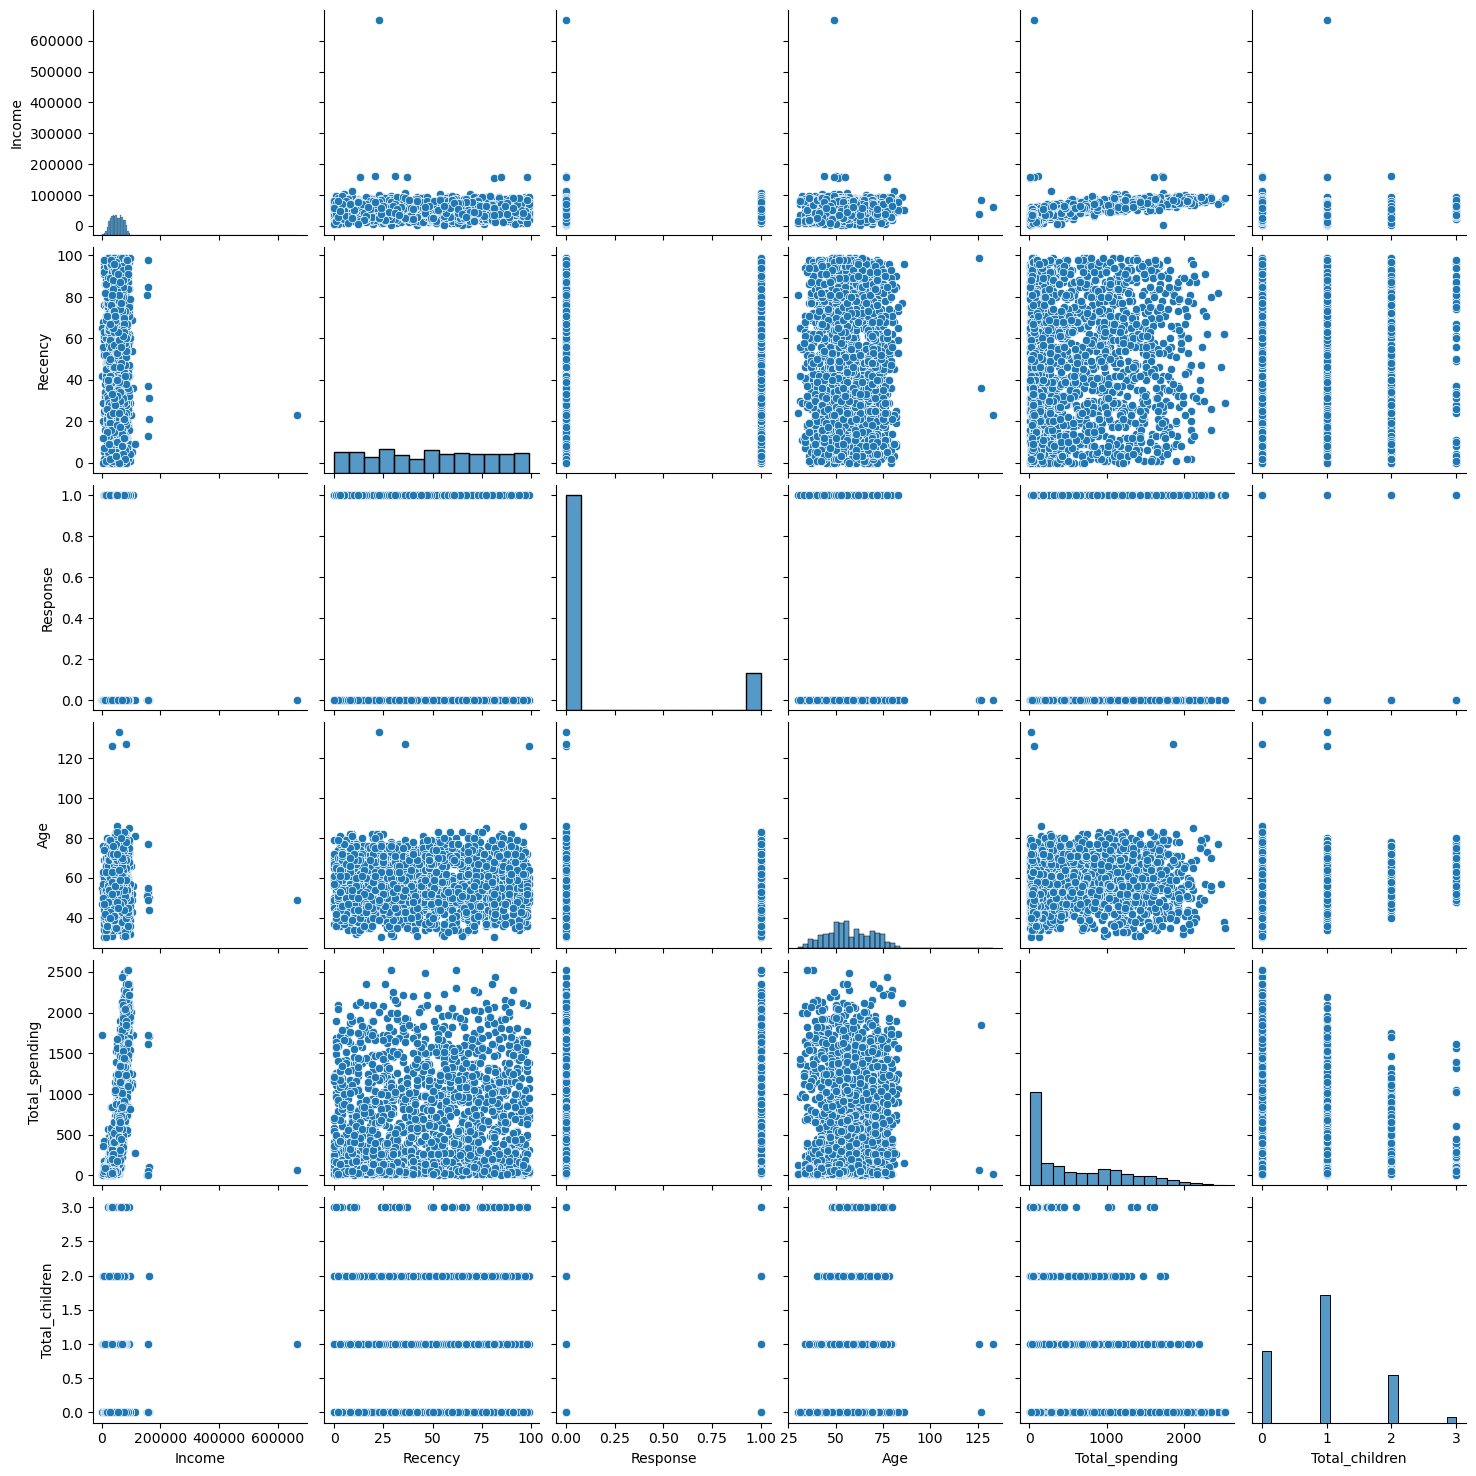

In [27]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_children"]

# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [28]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## HEATMAP

In [29]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

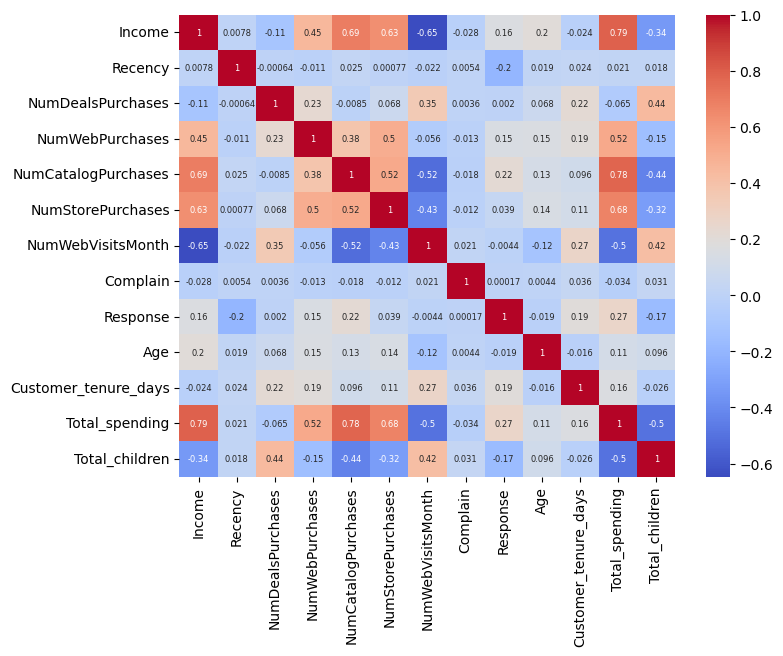

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

## ENCODING

In [31]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(
    enc_cols.toarray(),
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_cleaned.index
)

df_encoded = pd.concat(
    [df_cleaned.drop(columns=cat_cols), enc_df],
    axis=1
)

df_encoded.shape

(2236, 18)

## SCALING

In [32]:
from sklearn.preprocessing import StandardScaler


In [33]:
X = df_encoded

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## VISUALIZE

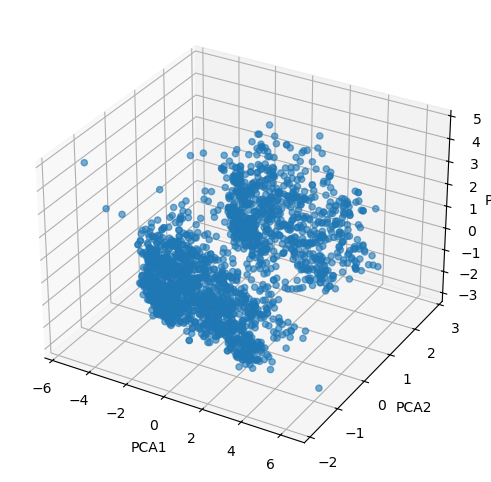

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:, 0],   # PCA1
    X_pca[:, 1],   # PCA2
    X_pca[:, 2],   # PCA3
    alpha=0.6
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.show()

# ANALYZE K VALUE


## 1. Elbow method

In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [37]:
knee = KneeLocator(
    range(1, 11),
    wcss,
    curve="convex",
    direction="decreasing"
)

optimal_k = knee.elbow

In [38]:
print("best k =", optimal_k)

best k = 4


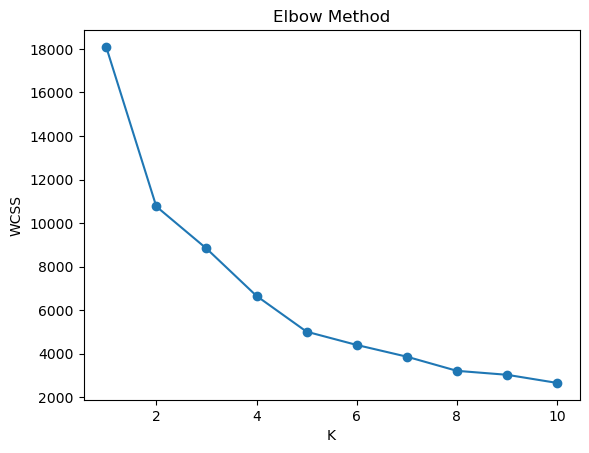

In [39]:
#plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 2. Silhouette score

In [40]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    scores.append(score)

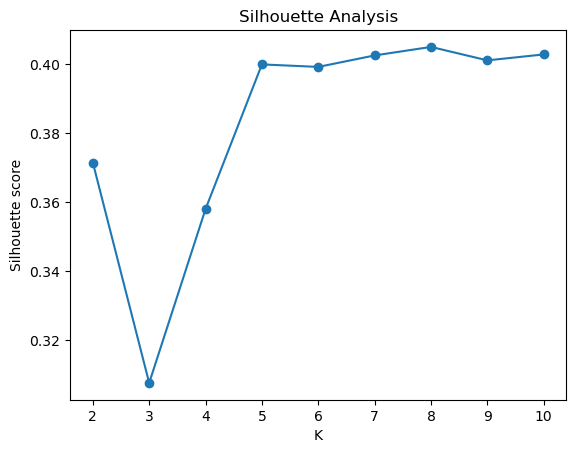

In [41]:
# plot

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis")
plt.show()

In [42]:
best_k = range(2, 11)[scores.index(max(scores))]
print("Best K =", best_k)
print("Best Silhouette Score =", max(scores))

Best K = 8
Best Silhouette Score = 0.40508588286833935


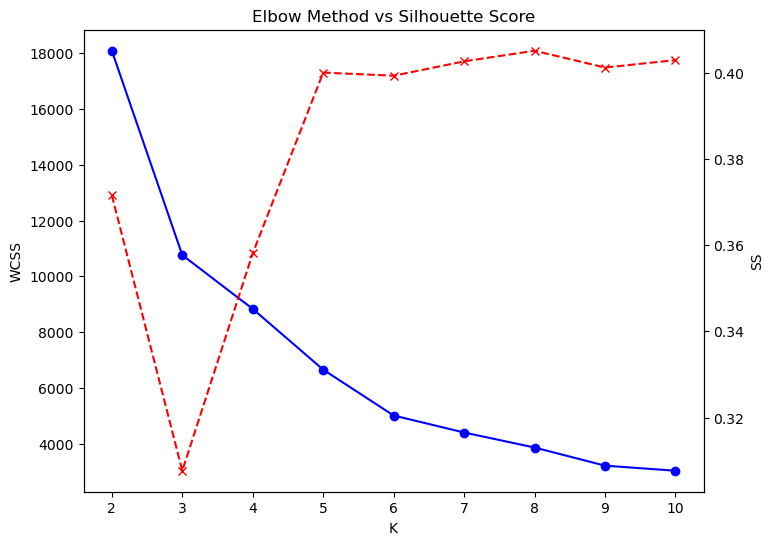

In [43]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()

ax2.plot(
    k_range,
    scores[:len(k_range)],
    marker="x",
    color="red",
    linestyle="--"
)
ax2.set_ylabel("SS")

plt.title("Elbow Method vs Silhouette Score")
plt.show()


## CLUSTERING

In [50]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters =4,
               random_state = 42)

labels_kmeans = kmeans.fit_predict(X_pca)

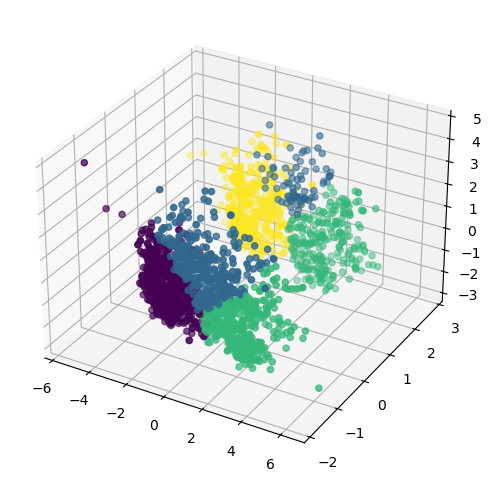

In [51]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

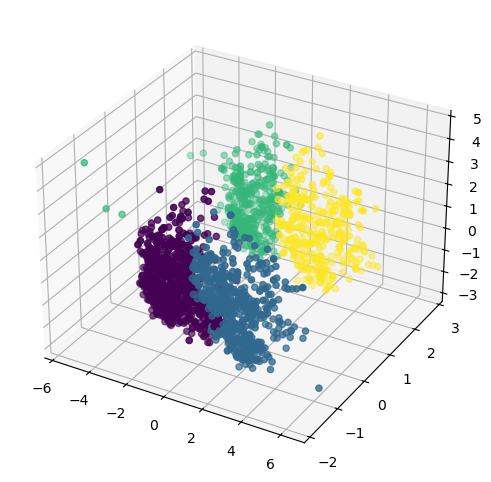

In [52]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)
plt.show()

## CHARACTERIZATION OF CLUSTERS

In [60]:
df_cleaned.drop("labels", axis=1)
df_cleaned["cluster"] = labels_agg

df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_children,Living_With,labels,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='cluster', ylabel='count'>

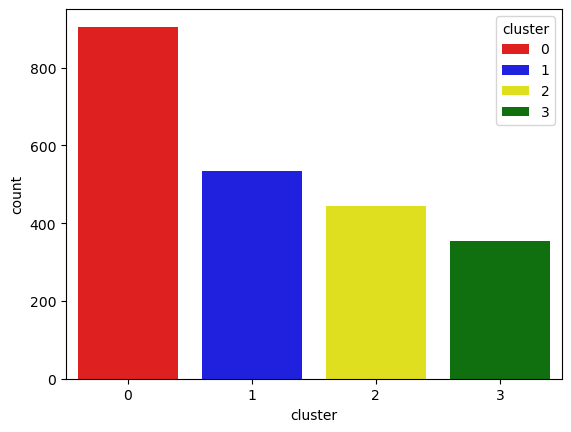

In [61]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(
    x=df_cleaned["cluster"],
    palette=pal,
    hue=df_cleaned["cluster"]
)

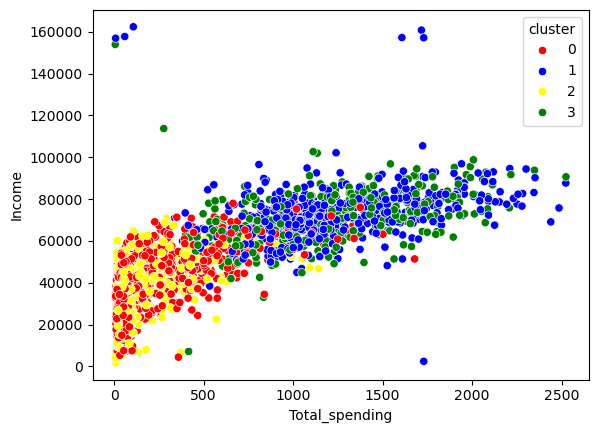

In [65]:
# Income & Spending patterns

sns.scatterplot(
    x=df_cleaned["Total_spending"],
    y=df_cleaned["Income"],
    hue=df_cleaned["cluster"],
    palette=pal
)

plt.show()

In [66]:
cluster_summary = df_cleaned.groupby("cluster").mean()

print(cluster_summary)

TypeError: agg function failed [how->mean,dtype->object]